In [1]:
import os
os.chdir('..')
print(os.getcwd())

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [2]:
from colab.SSO import SSO
import pandas as pd

def before_after(logs):
    before_list = []
    after_list = []
    for i in logs:
        SSO_reader = SSO()
        SSO_reader.load_result(i)
        before_log = SSO_reader.ckpt[0][0]['message']
        before = (
            0,
            0,
            before_log['train_time'],
            before_log['test_time'],  # 確保 test_cost 存在
            before_log['val_acc_4c'],
            before_log['test_acc_4c'],
            before_log['test_acc_3c'],
            before_log['test_acc_2c'],
            before_log['f1'],
            before_log['precision'],
            before_log['recall'],
            SSO_reader.ckpt[0][0]['x'][0] # params
        )

        # 取得最佳解的紀錄（最佳世代 genBest，最佳解 gBest）
        after_log = SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message']
        after = (
            SSO_reader.genBest,
            SSO_reader.gBest,
            after_log['train_time'],
            after_log['test_time'],
            after_log['val_acc_4c'],
            after_log['test_acc_4c'],
            after_log['test_acc_3c'],
            after_log['test_acc_2c'],
            after_log['f1'],
            after_log['precision'],
            after_log['recall'],
            SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'][0] # params
        )
        print(f"Fitness : {SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'][1]}")
        print(f"params : {SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'][0]}")
        print(before)
        print(after)
        before_list.append(before)
        after_list.append(after)
    return before_list, after_list

In [7]:
SSO_reader = SSO()
SSO_reader.load_result(r"C:\Users\User\Downloads\drunk_4_789_ggen15_gsol2_searchtime60477.525334358215_fec2a3da.pkl")
print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest])

❌ Unable to extract ggen and gsol from filename.


KeyError: 0

# 小樣本試驗

In [3]:
import os
import glob

# results_dir = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result"
results_dir = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\pso_result"
data = 'drunk'
split = 8
# hyp (789, 189, 129, 123)  348
hyp = 348

# 定義符合條件的檔案名稱模式
pattern = os.path.join(results_dir, f"PSO_{data}_{split}_*")

# 搜尋所有符合條件的檔案
logs = glob.glob(pattern)
before_list, after_list = before_after(logs)


🔄 Loading from saved checkpoint...
📂 File ggen: 5, gsol: 2
Fitness : 0.81640625
params : (4.0, 70.60544525540426, 1.0, 2.1968697282306495, 2.468558253496302, 0.0, 0.15761160464658971, 0.2160925564402191, 0.09626566088219772, 0.0, 0.8448862044148511, 0.592574669328258, 0.5406110047004912)
(0, 0, 83.07161927223206, 0.36034083366394043, 0.7802734375, 0.7694444444444445, 0.8868055555555555, 0.9847222222222223, 0.9844851904090267, 1.0, 0.9694444444444444, (4.0, 64.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0005, 0.9, 0.6, 0.5))
(5, 2, 89.4273247718811, 0.4183657169342041, 0.81640625, 0.7743055555555556, 0.8715277777777778, 0.9958333333333333, 0.99581589958159, 1.0, 0.9916666666666667, (4.0, 70.60544525540426, 1.0, 2.1968697282306495, 2.468558253496302, 0.0, 0.15761160464658971, 0.2160925564402191, 0.09626566088219772, 0.0, 0.8448862044148511, 0.592574669328258, 0.5406110047004912))

🔄 Loading from saved checkpoint...
📂 File ggen: 7, gsol: 1
Fitness : 0.8333333333333334
params : (1.01519260067

In [4]:
columns = ["Stage", "genBest", "gBest", "train_time", "test_time", "val_acc_4c", "test_acc_4c", "test_acc_3c", "test_acc_2c", "f1", "precision", "recall", "params"]

df_before = pd.DataFrame(before_list, columns=columns[1:])
df_before.insert(0, "Stage", "Before")

df_after = pd.DataFrame(after_list, columns=columns[1:])
df_after.insert(0, "Stage", "After")

# 合併兩個DataFrame
df_final = pd.concat([df_before, df_after], ignore_index=True)

# 保存為 CSV 檔案
csv_path = "before_after_results.csv"
df_final.to_csv(csv_path, index=False)
print("Done")

Done


# 收斂試驗

In [19]:
import os
import glob

results_dir = r"C:\Users\ADMIN\PycharmProjects\Gait\pyskl\sso_result"
data = 'drunk'
split = 1
# hyp (789, 189, 129, 189)
hyp = 123

# 定義符合條件的檔案名稱模式
pattern = os.path.join(results_dir, f"{data}_{split}_{hyp}_*")

# 搜尋所有符合條件的檔案
logs = glob.glob(pattern)
before_list, after_list = before_after(logs)

In [11]:
from colab.SSO import SSO

SSO_reader = SSO()
SSO_reader.load_result(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_129_ggen4_gsol2_searchtime9785.896945476532_ba63ad82.pkl")


🔄 Loading from saved checkpoint...
📂 File ggen: 4, gsol: 2


In [12]:
print(SSO_reader.ckpt[0][0]['message'])
print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'])
print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'])

{'train_cost': 142.3177, 'train_time': 131.44453692436218, 'test_time': 0.9166688919067383, 'val_acc_4c': 0.7890625, 'val_acc_3c': 0.9006696428571429, 'val_acc_2c': 0.9810267857142857, 'test_acc_4c': 0.7285714285714285, 'test_acc_3c': 0.8202380952380952, 'test_acc_2c': 0.9291666666666667, 'f1': 0.9246358454718175, 'precision': 0.9878213802435724, 'recall': 0.8690476190476191, 'log': 'results/record_20250321_193734_drunk_j_split1_4C-0.7286_3C-0.8202_2C-0.9292_2CP-0.9878_2CR-0.8690_2CF-0.9246.txt'}
{'train_cost': 250.3714, 'train_time': 239.40312957763672, 'test_time': 0.9823720455169678, 'val_acc_4c': 0.8314732142857143, 'val_acc_3c': 0.9419642857142857, 'val_acc_2c': 0.9988839285714286, 'test_acc_4c': 0.7517857142857143, 'test_acc_3c': 0.8535714285714285, 'test_acc_2c': 0.9535714285714286, 'f1': 0.9528985507246376, 'precision': 0.9669117647058824, 'recall': 0.9392857142857143, 'log': 'results/record_20250321_203707_drunk_j_split1_4C-0.7518_3C-0.8536_2C-0.9536_2CP-0.9669_2CR-0.9393_2CF-


🔄 Loading from saved checkpoint...
📂 File ggen: 9, gsol: 3

🔄 Loading from saved checkpoint...
📂 File ggen: 9, gsol: 3
8
9


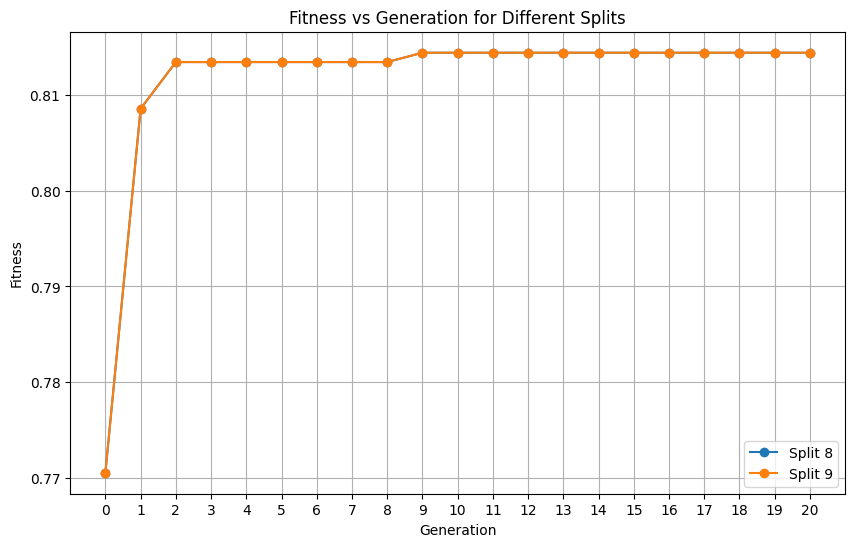

In [20]:
# SSO_reader.plot()
dic = {
    # '1' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_收斂實驗_ggen19_gsol3_searchtime50482.686158418655_ad53a19b.pkl",
    # '2' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_2_收斂實驗_ggen18_gsol8_searchtime41199.47251677513_7671076f.pkl",
    # '3' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_3_收斂實驗_ggen10_gsol15_searchtime53837.7646381855_8307643e.pkl",
    # '4' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_4_收斂實驗_ggen1_gsol0_searchtime38662.58326816559_71167b0c.pkl",
    # '5' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_5_收斂實驗_ggen17_gsol18_searchtime36103.59434223175_cecca1b9.pkl",
    '8' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_8_收斂實驗_ggen9_gsol3_searchtime47093.145209789276_cb224df1.pkl",
    '9' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_8_收斂實驗_ggen9_gsol3_searchtime47093.145209789276_cb224df1.pkl"
}   
data_list = []
entry = {}
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    for g in range(len(SSO_reader.ckpt)):
        if g == 0 :
            s = 0
        else:
            s = len(SSO_reader.ckpt[g]) -1
        param_values = SSO_reader.ckpt[g][s]['g'][0]
        fitness = SSO_reader.ckpt[g][s]['g'][1]
        entry = {
            'split': split,
            'generation': g,
            'fitness': fitness
        }
        data_list.append(entry)
df = pd.DataFrame(data_list)
import matplotlib.pyplot as plt
# 繪製圖表
plt.figure(figsize=(10, 6))

# 針對不同的 split 畫線
for split, group in df.groupby('split'):
    print(split)
    if split == '1':
        print(group['fitness'])
        group.loc[group.index[-6:], 'fitness'] = group['fitness'].iloc[-7]
    if split == '2':
        print(group['fitness'])
        group.loc[group.index[-6:], 'fitness'] = group['fitness'].iloc[-7]
    if split == '5':
        print(group['fitness'])
        group.loc[group.index[-6:], 'fitness'] = group['fitness'].iloc[-7]

    plt.plot(group['generation'], group['fitness'], label=f'Split {split}', marker='o', linestyle='-')


plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness vs Generation for Different Splits')
plt.xticks(df['generation'].astype(int).unique())
plt.legend()
plt.grid(True)
plt.show()
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'])
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'])


🔄 Loading from saved checkpoint...
📂 File ggen: 9, gsol: 3

🔄 Loading from saved checkpoint...
📂 File ggen: 9, gsol: 3


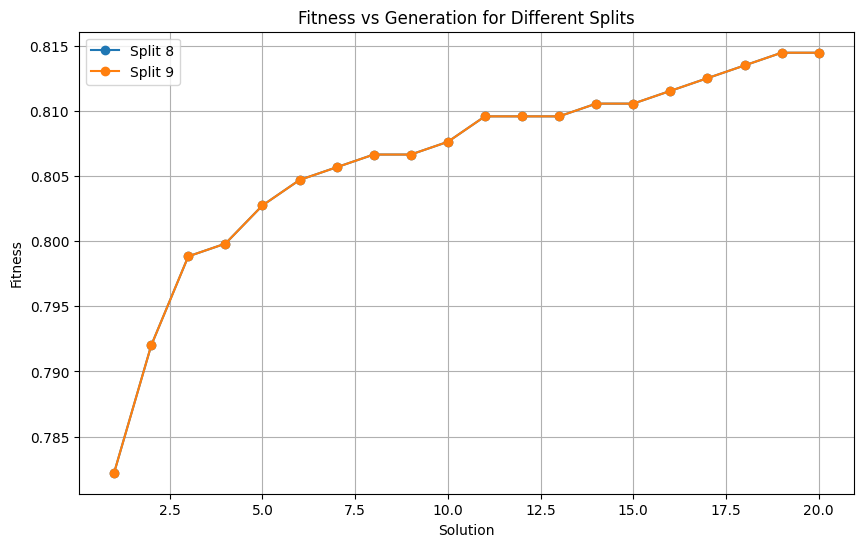

In [21]:
# SSO_reader.plot()
dic = {
    # '1' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_收斂實驗_ggen19_gsol3_searchtime50482.686158418655_ad53a19b.pkl",
    # '2' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_2_收斂實驗_ggen18_gsol8_searchtime41199.47251677513_7671076f.pkl",
    # '3' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_3_收斂實驗_ggen10_gsol15_searchtime53837.7646381855_8307643e.pkl",
    # '4' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_4_收斂實驗_ggen1_gsol0_searchtime38662.58326816559_71167b0c.pkl",
    # '5' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_5_收斂實驗_ggen17_gsol18_searchtime36103.59434223175_cecca1b9.pkl",
    '8' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_8_收斂實驗_ggen9_gsol3_searchtime47093.145209789276_cb224df1.pkl",
    '9' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_8_收斂實驗_ggen9_gsol3_searchtime47093.145209789276_cb224df1.pkl"
}   
data_list = []
entry = {}
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    g = 20
    for s in range(len(SSO_reader.ckpt[20])):
        param_values = SSO_reader.ckpt[g][s]['p'][0]
        fitness = SSO_reader.ckpt[g][s]['p'][1]
        entry = {
            'split': split,
            'sol': s,
            'fitness': fitness
        }
        data_list.append(entry)
df = pd.DataFrame(data_list)
import matplotlib.pyplot as plt
# 繪製圖表
plt.figure(figsize=(10, 6))

# 針對不同的 split 畫線
for split, group in df.groupby('split'):
    group = group.sort_values(by='fitness')
    group['sol'] = range(1, len(group) + 1)
    plt.plot(group['sol'], group['fitness'], label=f'Split {split}', marker='o', linestyle='-')

plt.xlabel('Solution')
plt.ylabel('Fitness')
plt.title('Fitness vs Generation for Different Splits')
plt.legend()
plt.grid(True)
plt.show()
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message'])
# print(SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['x'])

In [ ]:

# param_keys = [
#     'base_channel', 'num_init', 'num_in', 'tkernel_in', 'stride_in', 'oc_in',
#     'num_main', 'tkernel_main', 'stride_main', 'oc_main', 'act', 'opt',
#     'dropout_bk', 'dropout_fc', 'lr', 'weight_decay', 'momentum', 'margin', 'lambda_val'
# ]
# for split in range(1, 6):
#     SSO_reader = SSO()
#     SSO_reader.load_result(dic[split])

#     # 解析數據
#     data_list = []
#     for g in range(len(SSO_reader.ckpt)):
#         for s in range(len(SSO_reader.ckpt[g])):
#             param_values = SSO_reader.ckpt[g][s]['x'][0]
#             fitness = SSO_reader.ckpt[g][s]['x'][1]
#             entry = {param_keys[i]: param_values[i] for i in range(len(param_keys))}
#             entry['fitness'] = fitness
#             data_list.append(entry)

#     # 轉換為 DataFrame
#     df = pd.DataFrame(data_list)

#     import matplotlib.pyplot as plt
#     # 繪製散佈圖
#     for column in df.columns:
#         if column != 'fitness':  # 排除 fitness
#             if column == 'lr':
#                 df = df[df['fitness'] > 2.5]

#                 threshold = df['fitness'].quantile(0.8)
#                 top_20_df = df[df['fitness'] >= threshold]
#                 lr_max = top_20_df['lr'].max()
#                 lr_min = top_20_df['lr'].min()
#                 print(f"SPlit{split} : LR 最大值: {lr_max}, LR 最小值: {lr_min}")

#                 # print(f" LR: {df[column]} | fitness: {df['fitness']}")
#                 plt.figure(figsize=(6, 4))
#                 plt.scatter(df[column], df['fitness'], alpha=0.7)
#                 plt.xlabel(column)
#                 plt.ylabel("Fitness Score")
#                 plt.title(f"Scatter Plot: {column} vs Fitness")
#                 plt.grid(True)
#                 plt.show()

In [8]:
# SSO_reader.plot()
dic = {
    '1' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_1_479_收斂試驗_ggen11_gsol15_searchtime69759.33479952812_8cf451c5.pkl",
    '2' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_2_479_收斂試驗_ggen19_gsol11_searchtime70035.34123826027_cab74227.pkl",
    '3' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_3_479_收斂試驗_ggen10_gsol19_searchtime78091.5849096775_b909ca62.pkl",
    '4' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_4_479_收斂試驗_ggen18_gsol14_searchtime61293.00767827034_575d8835.pkl",
    '5' : r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\sso_result\drunk_5_479_收斂試驗_2_ggen12_gsol18_searchtime79429.0804259777_ed83dfaa.pkl",
}
data_list = []
entry = {}
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    message = SSO_reader.ckpt[SSO_reader.genBest][SSO_reader.gBest]['message']
    entry = {
        'split': split,
        'message': message
    }
    data_list.append(entry)
df = pd.DataFrame(data_list)
for s in df['message']:
    print(s)


🔄 Loading from saved checkpoint...
📂 File ggen: 11, gsol: 15

🔄 Loading from saved checkpoint...
📂 File ggen: 19, gsol: 11

🔄 Loading from saved checkpoint...
📂 File ggen: 10, gsol: 19

🔄 Loading from saved checkpoint...
📂 File ggen: 18, gsol: 14

🔄 Loading from saved checkpoint...
📂 File ggen: 12, gsol: 18
{'train_cost': 257.2094, 'train_time': 246.65261268615723, 'test_time': 0.5101666450500488, 'val_acc_4c': 0.8727678571428571, 'val_acc_3c': 0.9564732142857143, 'val_acc_2c': 0.9966517857142857, 'test_acc_4c': 0.7476190476190476, 'test_acc_3c': 0.8470238095238095, 'test_acc_2c': 0.9654761904761905, 'f1': 0.9645476772616138, 'precision': 0.9912060301507538, 'recall': 0.9392857142857143, 'log': 'results/record_20250323_060431_drunk_j_split1_4C-0.7476_3C-0.8470_2C-0.9655_2CP-0.9912_2CR-0.9393_2CF-0.9645.txt'}
{'train_cost': 395.9186, 'train_time': 384.1302328109741, 'test_time': 0.891798734664917, 'val_acc_4c': 0.8738839285714286, 'val_acc_3c': 0.9575892857142857, 'val_acc_2c': 1.0, 't

In [ ]:
import seaborn as sns
data_list = []
for split in dic.keys():
    SSO_reader = SSO()
    SSO_reader.load_result(dic[split])
    
    for g in range(len(SSO_reader.ckpt)):
        for s in range(len(SSO_reader.ckpt[0])):
            # 檢查是否有 message 欄位
            if 'message' not in SSO_reader.ckpt[g][s]:
                print(f"Warning: No 'message' key found in Split {split}, Generation {g}, Solution {s}")
                continue  # 跳過沒有 message 的數據

            # 檢查 message 欄位內是否有對應的 test_acc 數據
            message = SSO_reader.ckpt[g][s]['message']
            if not all(key in message for key in ['test_acc_4c', 'test_acc_3c', 'test_acc_2c']):
                print(f"Warning: Missing accuracy values in Split {split}, Generation {g}, Solution {s}")
                continue  # 跳過不完整的數據
            
            c4 = message['test_acc_4c']
            c3 = message['test_acc_3c']
            c2 = message['test_acc_2c']

            entry = {
                'split': split,
                'generation': g,
                'test_acc_4c': c4,
                'test_acc_3c': c3,
                'test_acc_2c': c2,
            }
            print(f"Adding entry: {entry}")  # Debug: 確保數據真的加入 data_list
            data_list.append(entry)

# 檢查 data_list 是否有數據
if len(data_list) == 0:
    print("Error: data_list 仍然為空，請檢查 SSO_reader.load_result() 是否正確讀取數據")
else:
    print(f"data_list 共有 {len(data_list)} 筆數據")

# 轉換 data_list 為 DataFrame
df = pd.DataFrame(data_list)

# 確保 DataFrame 不是空的
if df.empty:
    print("DataFrame 仍然為空，無法進行分析")
else:
    unique_splits = df['split'].unique()

    for split in unique_splits:
        df_split = df[df['split'] == split]

        # 繪製相關係數矩陣熱力圖
        correlation_matrix = df_split[['test_acc_4c', 'test_acc_3c', 'test_acc_2c']].corr()

        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title(f"Correlation Matrix for Split {split}")
        plt.show()

        # 繪製 pairplot 來顯示變數之間的散佈圖
        sns.pairplot(df_split, vars=['test_acc_4c', 'test_acc_3c', 'test_acc_2c'], diag_kind='kde')
        plt.suptitle(f"Pairplot for Split {split}", y=1.02)
        plt.show()